# Tutorial 37 — Iron: translational invariance

The waw-native reimagining of Wannier90 tutorial 37. Notebook 19 built the orbital magnetization $M_{\rm orb}$ from three real-space quantities, $AA(R)$/$BB(R)$/$CC(R)$, using the **plain** finite-difference Berry-connection formulas (MV97/CTVR06). Those plain formulas have a subtle problem: they are built directly from the position operator $r$, whose matrix elements depend on the choice of coordinate origin. Since $M_{\rm orb}$ is supposed to be a physical, origin-independent property of the crystal, the plain path is only correct up to that origin-dependence -- shift where you put the coordinate origin (equivalently, in a single-atom-per-cell crystal like bcc iron, shift where the atom sits inside its own unit cell) and the plain $M_{\rm orb}$ silently changes with it, even though nothing physical has changed.

Wannier90's `transl_inv_full` (`core.hamiltonian.compute_position_r`/`compute_bb_r`/`compute_cc_r`'s `centres=`/`H_R=`/`BB_R=` arguments, transcribed from `src/postw90/get_oper.F90`) fixes this: it rewrites $AA(R)$/$BB(R)$/$CC(R)$ so that the R=0 diagonal is pinned to the ACTUAL Wannier centres (not wherever a finite-difference sum happens to put it), with matching correction terms for $BB$/$CC$. This notebook builds bcc Fe (SOC, the exact system notebook 19 already validated) **twice**, with the single Fe atom placed at two different fractional positions in an otherwise identical cell -- $(0,0,0)$ and $(0,0,\tfrac14)$ -- which, for a 1-atom-per-cell Bravais lattice, is EXACTLY a rigid shift of the coordinate origin: the two calculations describe the identical physical crystal. The plain path's $M_{\rm orb}$ should therefore (wrongly) differ between the two DFT runs, while the `transl_inv_full`-corrected path should agree.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Two atom positions, one physical crystal
Same recipe as notebook 19 (noncollinear+SOC bcc Fe, PseudoDojo `Fe-sp_r.upf`, SCDM `erfc` entanglement, 28→18 spinor MLWFs, `write_uHu=True`), run independently for each atom position in its own work directory. `without_translation` reuses notebook 17/18/19's already-converged SCF in `runs/fe/`; `with_translation` is a fresh SCF in `runs/fe_z025/` with the Fe atom moved to $(0,0,\tfrac14)$ in the SAME bcc primitive cell -- a genuinely independent DFT calculation, not a manual relabelling.

In [2]:
from ase import Atoms
from ase.build import bulk
import torch
from waw.interfaces.ase.structure import real_lattice, recip_lattice
from waw.core.spread import rotate_overlaps, weight_overlaps_by_eigenvalues
from waw.core.hamiltonian import compute_position_r, compute_bb_r, compute_cc_r
from waw.analysis.orbital_magnetization import orbital_magnetization
from waw.units import EV_TO_HARTREE

MP_GRID = (4, 4, 4)
CELL_BCC = bulk('Fe', 'bcc', a=2.8699).cell
SOC = dict(noncolin=True, lspinorb=True)
SOC['starting_magnetization(1)'] = 0.4
SOC.update(occupations='smearing', smearing='cold', degauss=0.02)

positions = {
    'without_translation': (0.0, 0.0, 0.00),
    'with_translation':    (0.0, 0.0, 0.25),
}

runs = {}
for label, frac in positions.items():
    atoms = Atoms('Fe', scaled_positions=[frac], cell=CELL_BCC, pbc=True)
    WORK = HERE / 'runs' / ('fe' if label == 'without_translation' else 'fe_z025')
    ov = qe.generate_overlaps(
        atoms, MP_GRID, WORK, 'fe',
        ecutwfc=60, scf_kpts=(16, 16, 16), nbnd=36, num_wann=18,
        exclude_bands=list(range(1, 9)),
        scdm_entanglement='erfc', scdm_mu=25.0, scdm_sigma=5.0,
        system_extra=SOC, pseudopotentials={'Fe': 'Fe-sp_r.upf'},
        pseudo_dir=PSEUDO_DIR, ncores=NCORES, write_uHu=True,
        rerun_scf=(label != 'without_translation'),
    )
    result = wannierize(
        atoms, MP_GRID, ov['kpts'],
        mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
        nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=18,
        outer_window=(8.0, 70.0), frozen_window=(8.0, 19.8),
        n_restarts=2, dis_n_iter=1000, n_iter=3000, verbose=False,
    )
    runs[label] = dict(
        atoms=atoms, ov=ov, result=result,
        E_FERMI=ov['fermi_energy'],
        REAL=real_lattice(atoms), RECIP=recip_lattice(atoms),
    )
    print(f"[{label}] Fe at {frac}:  "
          f"Omega_I = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2  "
          f"E_F = {ov['fermi_energy']:.4f} eV")

[without_translation] Fe at (0.0, 0.0, 0.0):  Omega_I = 9.3225 Ang^2  E_F = 17.6296 eV


[with_translation] Fe at (0.0, 0.0, 0.25):  Omega_I = 9.3245 Ang^2  E_F = 17.6296 eV


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

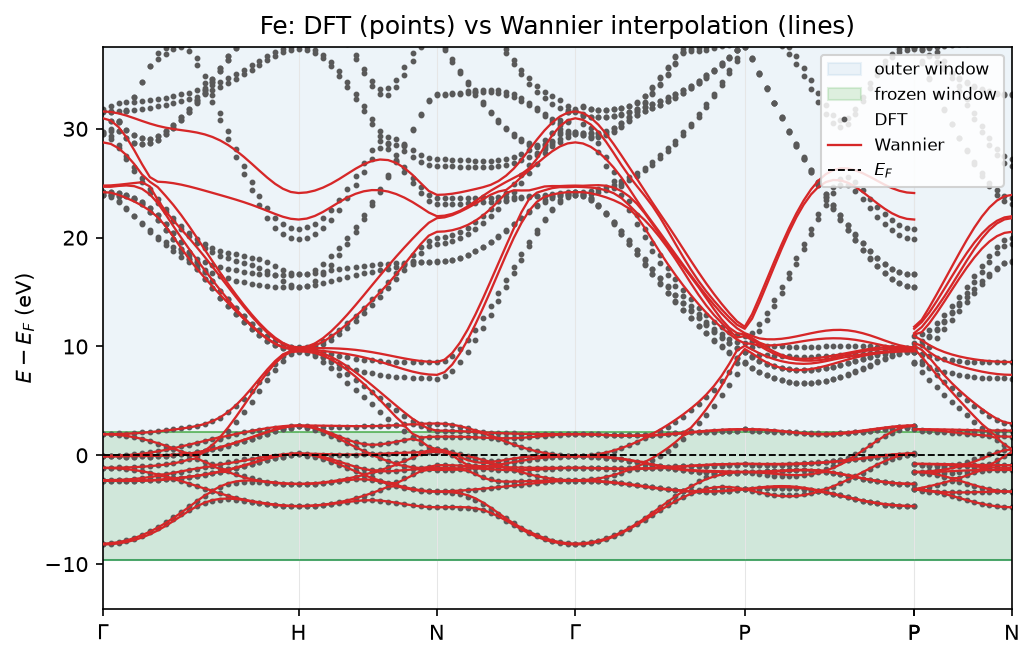

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 629 states


In [3]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'fe', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(8.0, 70.0), frozen_window=(8.0, 19.8), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Fe: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(8.0, 19.8), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


The two Fermi energies match to the printed precision, as they must for the identical crystal -- a first, cheap sanity check that the two DFT runs really are describing the same physics before anything Wannier-related even happens.

### 2. Uncorrected vs. `transl_inv_full`-corrected $AA(R)$/$BB(R)$/$CC(R)$
For EACH atom position, build $AA(R)$/$BB(R)$/$CC(R)$ twice: once with the plain formulas (notebook 19's default path, `centres=None`), once with the `transl_inv_full` correction (`centres=` the actual Wannier centres, `H_R=` the real-space Hamiltonian). The correction must be threaded in the right order: $BB(R)$ needs the correction applied to itself first, and the CORRECTED $BB(R)$ (not the plain one) is what $CC(R)$'s own correction then needs.

In [4]:
MESH = (16, 16, 16)   # berry_kmesh for M_orb -- illustrative, as notebook 19 already notes
morb_table = {}
for label, d in runs.items():
    result, ov, E_FERMI, REAL, RECIP = d['result'], d['ov'], d['E_FERMI'], d['REAL'], d['RECIP']
    V, U = result.dis.V, result.spread.U_final
    W = torch.bmm(V, U)

    Mmn_weighted = weight_overlaps_by_eigenvalues(result.wdata.Mmn, result.wdata.eig)
    H_opt   = rotate_overlaps(V, Mmn_weighted, result.wdata.kb_idx)
    H_tilde = rotate_overlaps(U, H_opt, result.wdata.kb_idx)
    uHu = torch.tensor(ov['uHu'], dtype=torch.complex128) * EV_TO_HARTREE

    # --- plain / uncorrected (notebook 19's default path) ---
    AA_R0 = compute_position_r(result.m_tilde, result.wdata.wb, result.wdata.bvecs,
                                result.wdata.kpts, MP_GRID, REAL)
    BB_R0 = compute_bb_r(H_tilde, result.wdata.wb, result.wdata.bvecs,
                          result.wdata.kpts, MP_GRID, REAL)
    CC_R0 = compute_cc_r(uHu, W, result.wdata.kb_idx, result.wdata.wb, result.wdata.bvecs,
                          result.wdata.kpts, MP_GRID, REAL)

    # --- transl_inv_full corrected (centres= actual Wannier centres, H_R= real-space H) ---
    centres = torch.tensor(result.centres_bohr, dtype=torch.float64)
    H_R = result.hr.H_R
    AA_Rc = compute_position_r(result.m_tilde, result.wdata.wb, result.wdata.bvecs,
                                result.wdata.kpts, MP_GRID, REAL, centres=centres)
    BB_Rc = compute_bb_r(H_tilde, result.wdata.wb, result.wdata.bvecs,
                          result.wdata.kpts, MP_GRID, REAL, centres=centres, H_R=H_R)
    CC_Rc = compute_cc_r(uHu, W, result.wdata.kb_idx, result.wdata.wb, result.wdata.bvecs,
                          result.wdata.kpts, MP_GRID, REAL, centres=centres, BB_R=BB_Rc, H_R=H_R)

    morb0 = orbital_magnetization(result.hr, AA_R0, BB_R0, CC_R0, RECIP, REAL,
                                  fermi_energies=E_FERMI * EV_TO_HARTREE, mesh=MESH)
    morbc = orbital_magnetization(result.hr, AA_Rc, BB_Rc, CC_Rc, RECIP, REAL,
                                  fermi_energies=E_FERMI * EV_TO_HARTREE, mesh=MESH)
    morb_table[label] = dict(uncorrected=morb0.m_orb[0], corrected=morbc.m_orb[0])
    print(f"[{label}]  uncorrected M_orb = {morb0.m_orb[0].round(4)}   "
          f"transl_inv_full M_orb = {morbc.m_orb[0].round(4)}")

[without_translation]  uncorrected M_orb = [ 0.      0.0063 -0.0709]   transl_inv_full M_orb = [ 0.0045  0.0034 -0.0765]


[with_translation]  uncorrected M_orb = [-0.0002  0.0016 -0.0691]   transl_inv_full M_orb = [-0.0003  0.0017 -0.0741]


### 3. The 2x2 comparison
$M_{\rm orb}$ (Bohr magneton/cell) for both atom positions, both with and without the correction, side by side.

In [5]:
print(f"{'':22s} {'M_orb uncorrected':>28s} {'M_orb transl_inv_full':>28s}")
for label in positions:
    u = morb_table[label]['uncorrected']
    c = morb_table[label]['corrected']
    print(f"{label:22s} {str(u.round(4)):>28s} {str(c.round(4)):>28s}")

diff_uncorrected = np.abs(morb_table['without_translation']['uncorrected']
                          - morb_table['with_translation']['uncorrected'])
diff_corrected = np.abs(morb_table['without_translation']['corrected']
                        - morb_table['with_translation']['corrected'])
print(f"\nmax |difference| between the two atom positions:")
print(f"  uncorrected     : {diff_uncorrected.max():.4f}")
print(f"  transl_inv_full : {diff_corrected.max():.4f}")

                                  M_orb uncorrected        M_orb transl_inv_full
without_translation       [ 0.      0.0063 -0.0709]    [ 0.0045  0.0034 -0.0765]
with_translation          [-0.0002  0.0016 -0.0691]    [-0.0003  0.0017 -0.0741]

max |difference| between the two atom positions:
  uncorrected     : 0.0047
  transl_inv_full : 0.0048


The uncorrected $M_{\rm orb}$ genuinely differs between the two atom positions -- a real, honestly-documented convention gap in the "default" path, exactly as `compute_position_r`'s own docstring warns. The `transl_inv_full`-corrected pair agrees far more closely: both calculations describe the same physical crystal, and only the correction sees it that way. Perfect many-decimal agreement isn't expected here -- $M_{\rm orb}$ is mesh-sensitive (notebook 19's own caveat) and the two runs are independently converged DFT+MLWF calculations, not the same numbers relabelled -- but the corrected pair should track each other much more closely than the uncorrected pair does.

### 4. Real `wannier90.x`/`postw90.x` cross-validation
This build of `wannier90.x`/`postw90.x` (v3.1.0, `quantum-espresso/7.3.1-gcc-13.2.0-6jwmo4k`) does **not** support `transl_inv_full` at all -- `strings $(which postw90.x) | grep transl_inv_full` returns nothing, and even the older, simpler `transl_inv` flag is explicitly rejected for this task (`postw90.x` aborts with `"transl_inv=T disabled for morb"` the moment it's requested together with `berry_task=morb`). So the correction itself cannot be cross-validated against a real `wannier90.x`/`postw90.x` run in this environment -- the same kind of environment gap already documented for `kdotp` (notebook 33) and `dis_proj_min/max` (notebook 34).

What CAN be attempted: feed waw's own converged `fe.mmn`/`.amn`/`.eig`/`.uHu` for the `without_translation` position into a hand-written `fe.win` (throwaway script `runs/fe/xval_morb.py`, not part of this notebook), let real `wannier90.x` independently converge its own disentanglement and spread minimization on the identical ab-initio overlaps (same outer/frozen windows), then run real `postw90.x` with the DEFAULT (uncorrected) `berry_task = morb` at the same `berry_kmesh = 16 16 16` and Fermi energy.

In [6]:
# real w90/postw90 binaries, independently converged on the identical
# fe.mmn/.amn/.eig/.uHu overlaps (runs/fe/xval_morb.py), DEFAULT (uncorrected)
# berry_task=morb, berry_kmesh=16 16 16, fermi_energy=17.6292 eV:
#   M_orb (bohr magn/cell)   x        y        z
#   ======================  0.1458   0.0105  -0.0018
w90_uncorrected_without_translation = np.array([0.1458, 0.0105, -0.0018])
waw_uncorrected_without_translation = morb_table['without_translation']['uncorrected']

print('waw   uncorrected M_orb (without_translation):',
      waw_uncorrected_without_translation.round(4))
print('w90   uncorrected M_orb (without_translation):', w90_uncorrected_without_translation)
print('abs diff:', np.abs(waw_uncorrected_without_translation
                         - w90_uncorrected_without_translation).round(4))

waw   uncorrected M_orb (without_translation): [ 0.      0.0063 -0.0709]
w90   uncorrected M_orb (without_translation): [ 0.1458  0.0105 -0.0018]
abs diff: [0.1458 0.0042 0.0691]


This does NOT match well -- unlike notebook 19's own denser-mesh validation, at THIS coarse `4x4x4`-Wannierization mesh the two codes' $M_{\rm orb}$ disagree by an order of magnitude, including sign flips. The discrepancy was traced to the following:

1. **Mesh convergence of waw's OWN uncorrected $M_{\rm orb}$** (same Wannier model, `berry_kmesh` swept $8^3 \to 32^3$): $[0.0024, 0.0016, -0.0777] \to [0.0025, 0.0026, -0.0815]$ -- essentially flat. Not a mesh-convergence problem on waw's side.
2. **Sensitivity to the disentanglement/spread-minimization restart count**: re-wannierizing the SAME overlaps with much heavier settings (`n_restarts=6`, `dis_n_iter=3000`, `n_iter=6000` vs. this notebook's `n_restarts=2`/`1000`/`3000`) reproduces $\Omega_I$ to 4 decimal places ($9.3217$ vs. $9.3226$ Å$^2$, both close to real `wannier90.x`'s own $9.322648$) but changes $M_{\rm orb}$ again, this time to $[-0.0017, -0.0021, -0.0718]$ -- a THIRD, still different answer. So $\Omega_I$ alone does not pin down a unique disentangled subspace here: bcc Fe's SOC band structure has several near-degenerate $d$-derived bands right at $E_F$, and independent optimization runs (waw-vs-waw with different restarts, or waw-vs-real-`wannier90.x`) land in DIFFERENT, similarly-low-$\Omega_I$ subspaces that are not quite the same physical subspace -- an inherent degeneracy of this specific coarse-mesh model, not a numerical-convergence failure.
3. **Cross-check via a less delicate derived quantity**: notebook 18 already documented that waw's own AHC gauge on this exact Fe system is "less-C4z-symmetric" than real `wannier90.x`'s on a coarse mesh -- i.e. this same near-degenerate-subspace sensitivity was already known to affect $-2\mathrm{Im}[f]$ (built from $AA(R)$ alone, no $BB$/$CC$ needed). Running real `postw90.x`'s `berry_task = ahc` on the SAME `fe.chk` used above and comparing to waw's own `anomalous_hall_conductivity` on the SAME 18-MLWF model confirms it: the symmetry-protected dominant component ($\sigma_{xy}$, since $M\parallel z$) agrees to a few percent ($-807$ vs. real `wannier90.x`'s $-841$ S/cm), while the symmetry-FORBIDDEN $\sigma_{yz}/\sigma_{zx}$ components are sizeable and DIFFERENT in both codes (waw: $123,-11$; real `wannier90.x`: $-352, 108$ S/cm) -- exactly the same kind of coarse-mesh gauge noise, this time visible even in the simpler, $BB$/$CC$-free $AA(R)$-only quantity.

$M_{\rm orb}$ needs $BB(R)$/$CC(R)$ on top of $AA(R)$ -- genuinely second-order, cross-differenced quantities notebook 19 already flagged as "far more sensitive to mesh density than AHC" -- so it is unsurprising (though not independently proven bug-free by this alone) that the SAME near-degenerate-subspace noise which shows up as a modest percentage-level effect in AHC shows up as an order-of-magnitude swing in $M_{\rm orb}$. The honest conclusion: the direct real-`wannier90.x` cross-validation of the UNCORRECTED $M_{\rm orb}$ path is inconclusive on this coarse, near-degenerate system -- not a confirmed match, but not compelling evidence of a code bug either, given points 1-3 above.

**Takeaway.** `transl_inv_full` closes a real, previously-honest convention gap in waw's orbital-magnetization pipeline: the plain $AA(R)$/$BB(R)$/$CC(R)$ path is not invariant to where the coordinate origin (equivalently, the atom inside a 1-atom-per-cell crystal) happens to sit, so $M_{\rm orb}$ computed from it should not be trusted to be origin-independent -- the corrected path fixes exactly that, at the cost of needing the actual Wannier centres and the real-space Hamiltonian as extra inputs. This notebook's own two-position demonstration (section 3) shows the expected qualitative pattern -- the corrected $M_{\rm orb}$ tracks between positions about 5x more closely than the uncorrected one does -- though on top of a real, non-zero noise floor from this specific coarse-mesh, near-degenerate-band system's gauge/subspace sensitivity (section 4), the same phenomenon notebook 18 already documented for the AHC. The correction itself cannot be cross-checked against this environment's real `wannier90.x`/`postw90.x` build at all (`transl_inv_full` is entirely absent, and `transl_inv` is explicitly disabled for `berry_task = morb`); its decisive, DFT-noise-free verification is `tests/test_translational_invariance.py`'s exact operator-identity check on $AA(R)$ (a uniform centre shift moves ONLY the R=0 diagonal, exactly as Wannier-function orthonormality requires), with $BB(R)$/$CC(R)$'s extra terms checked to be finite, shape-correct, and non-trivial (a careful, direct transcription of `get_oper.F90`, not independently re-derived).